# Child model V&V: all-cause mortality

Version-free filename by convention: rerun against each model iteration's results and commit,
so run-over-run diffs fall out of git history. The LBWSG relative-risk and PAF checks that used
to live here moved to `child_lbwsg.ipynb`, which verifies them against a live `InteractiveContext`
of the child model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from vivarium.artifact import Artifact

from lsff_utils import paths

location = "nigeria"
vehicle = "bouillon"
model_number = paths.MODEL_NUMBER  # the archived iteration to check; set explicitly to read an older one

# The run comes from the marker archive_last_run.sh copies beside the run directories,
# so this is the run the pipeline published -- no timestamp to paste in.
results_dir = paths.latest_results(
    paths.archive_root(paths.CHILD_RESULTS_ROOT, model_number), location, vehicle
)
artifact_dir = paths.artifact_path(
    paths.archive_root(paths.CHILD_ARTIFACT_ROOT, model_number), location, vehicle
)
print(f"{model_number} {vehicle}/{location}\n  results:  {results_dir}\n  artifact: {artifact_dir}")
art = Artifact(artifact_dir)

model1.2 bouillon/nigeria
  results:  /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/results/model1.2/child/bouillon/nigeria/2026_09_08_22_21_29/results
  artifact: /mnt/team/simulation_science/pub/models/vivarium_gates_lsff_2026/artifacts/model1.2/child/bouillon/nigeria.hdf


## All-cause mortality: sim vs artifact

The artifact rate is drawn as the step function the sim actually looks up (lookup interpolation
is order 0, so the rate is constant within each artifact age bin). The sim's measured
deaths / person-time is drawn as a bar spanning each output age bin, so it is explicit which
artifact bins each sim value mixes together. The dashed line over each bar is the expected
mixture: deaths / person-time over that age range under the artifact's piecewise-constant
hazard (person-time weighting via the implied survival curve) -- the bar should sit on it.
Both first bins start at age 0; the log axis clips their left edge to the plot minimum.

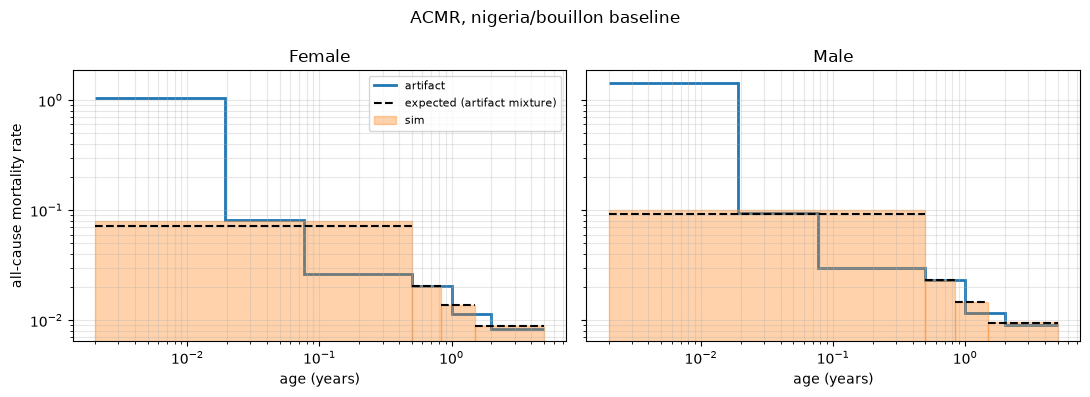

In [2]:
deaths = pd.read_parquet(paths.measure_path(results_dir, "deaths"))
pt = pd.read_parquet(paths.measure_path(results_dir, "person_time_population"))
cols = ["maternal_scenario", "child_scenario", "sex", "age_group"]
acmr = (deaths.groupby(cols).value.sum() / pt.groupby(cols).value.sum()).rename("sim")
acmr = acmr.xs(("baseline", "baseline")).reset_index()
sim_bins = {
    "0_to_5_months": (0.0, 0.5),
    "6_to_9_months": (0.5, 10 / 12),
    "10_to_17_months": (10 / 12, 1.5),
    "18_to_59_months": (1.5, 5.0),
}

art_acmr = art.load("cause.all_causes.cause_specific_mortality_rate")["draw_0"].reset_index()
art_acmr = art_acmr[art_acmr.age_start < 5].sort_values("age_start")


def mixture_rate(art_sex, lo, hi):
    """Deaths / person-time over [lo, hi) under the artifact's piecewise-constant hazard."""
    total_deaths = total_pt = 0.0
    survival = 1.0  # conditional on reaching lo; the constant cancels in the ratio
    for _, row in art_sex.iterrows():
        a, b = max(row.age_start, lo), min(row.age_end, hi)
        if a >= b:
            continue
        died = survival * (1 - np.exp(-row.draw_0 * (b - a)))
        total_deaths += died
        total_pt += died / row.draw_0
        survival -= died
    return total_deaths / total_pt


X_MIN = 2e-3
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, sex in zip(axes, ["Female", "Male"]):
    a = art_acmr[art_acmr.sex == sex]
    edges = np.append(a.age_start.values, a.age_end.values[-1]).clip(min=X_MIN)
    ax.stairs(a.draw_0.values, edges, baseline=None, color="C0", lw=2, label="artifact")
    for i, (age_group, (lo, hi)) in enumerate(sim_bins.items()):
        v = acmr.loc[(acmr.sex == sex) & (acmr.age_group == age_group), "sim"].iloc[0]
        ax.bar(max(lo, X_MIN), v, width=hi - max(lo, X_MIN), align="edge",
               color="C1", alpha=0.35, edgecolor="C1", label="sim" if i == 0 else None)
        ax.hlines(mixture_rate(a, lo, hi), max(lo, X_MIN), hi, color="k", ls="--",
                  lw=1.5, label="expected (artifact mixture)" if i == 0 else None)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(which="both", alpha=0.3)
    ax.set_title(sex)
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("all-cause mortality rate")
axes[0].legend(fontsize=8)
fig.suptitle(f"ACMR, {location}/{vehicle} baseline")
fig.tight_layout()

The same comparison, numerically: `ratio` = observed / expected artifact mixture. `poisson_se`
is the floor on the ratio's sampling noise from the death count alone (between-seed clustering
makes the true noise somewhat larger), so ratios within ~2 of it are unremarkable.

In [3]:
q = "maternal_scenario == 'baseline' and child_scenario == 'baseline'"
rows = []
for sex in ["Female", "Male"]:
    a = art_acmr[art_acmr.sex == sex]
    for age_group, (lo, hi) in sim_bins.items():
        obs = acmr.loc[(acmr.sex == sex) & (acmr.age_group == age_group), "sim"].iloc[0]
        expected = mixture_rate(a, lo, hi)
        n_deaths = deaths.query(q).pipe(
            lambda d: d[(d.sex == sex) & (d.age_group == age_group)]
        ).value.sum()
        rows.append((sex, age_group, int(n_deaths), obs, expected, obs / expected))
summary = pd.DataFrame(
    rows, columns=["sex", "age_group", "deaths", "observed_acmr", "expected_acmr", "ratio"]
)
summary["poisson_se"] = 1 / np.sqrt(summary.deaths)
print(summary.round(4).to_string(index=False))

   sex       age_group  deaths  observed_acmr  expected_acmr  ratio  poisson_se
Female   0_to_5_months   98427         0.0793         0.0719 1.1033      0.0032
Female   6_to_9_months   16943         0.0205         0.0206 0.9959      0.0077
Female 10_to_17_months   21836         0.0138         0.0137 1.0045      0.0068
Female 18_to_59_months   72728         0.0088         0.0088 0.9994      0.0037
  Male   0_to_5_months  130872         0.1011         0.0929 1.0878      0.0028
  Male   6_to_9_months   19770         0.0230         0.0231 0.9952      0.0071
  Male 10_to_17_months   23915         0.0145         0.0145 0.9971      0.0065
  Male 18_to_59_months   81950         0.0095         0.0095 1.0040      0.0035
